<a href="https://colab.research.google.com/github/Saibot2012/long-exposure-fusion/blob/main/pw3_nonlinearfiltering_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Work 3: Non-linear filtering with Mathematical Morphology

The aim of this practical work is to get acquainted with mathematical morphology
transformations. Applying different operations with several structuring elements on
simple images will allow you understanding the actions, effects and properties of the
operations, the role of the structuring element, as well as the need for appropriate
pre-processing depending on the application at hand.

In this session, we will mainly focus on functions from the skimage.morphology package.

In [1]:
#Dowmloading images
!wget https://perso.telecom-paristech.fr/aleclaire/athens/imagesTP2.zip
!unzip -qq imagesTP2.zip
!rm imagesTP2.zip

--2026-04-09 06:40:58--  https://perso.telecom-paristech.fr/aleclaire/athens/imagesTP2.zip
Resolving perso.telecom-paristech.fr (perso.telecom-paristech.fr)... 137.194.22.227, 2a04:8ec0:0:a::89c2:16e3
Connecting to perso.telecom-paristech.fr (perso.telecom-paristech.fr)|137.194.22.227|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 554230 (541K) [application/zip]
Saving to: ‘imagesTP2.zip’

imagesTP2.zip       100%[===================>] 541.24K   551KB/s    in 1.0s    

2026-04-09 06:41:01 (551 KB/s) - ‘imagesTP2.zip’ saved [554230/554230]



In [4]:
## imports
import matplotlib.pyplot as plt
import numpy as np
import skimage.morphology as morpho
import skimage.segmentation as segmentation
student = True

## Structuring element

The basic idea in mathematical morphology is to probe an image with a simple, pre-defined shape, drawing conclusions on how this shape fits or misses the shapes in the image. This simple "probe" is called the structuring element. For example, it can take the shape of a square, a disk or a diamond, with a predefined radius.

Use the functions of the morpho library to visualize a disk structuring element of radius 3.

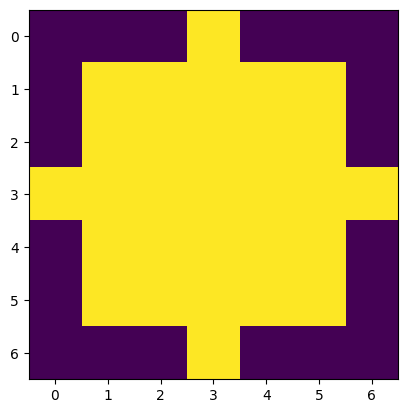

In [5]:
strell = morpho.disk(3)

plt.imshow(strell)
plt.show()

Find a way to create a vertical or horizontal line as a structuring element with parameter l :

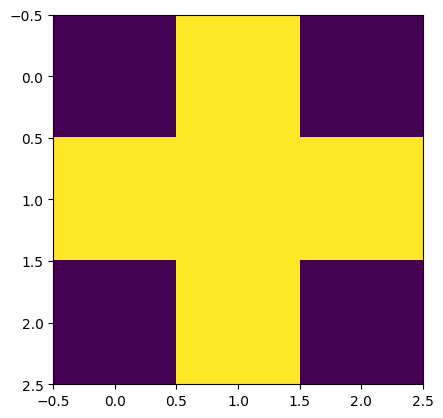

In [6]:
l = 5
strell_line = morpho.disk(1)
plt.imshow(strell_line)
plt.show()

## Binary Dilation and Erosion

In this section, we will work on a cyto-image. Make sure to properly load the "cell.tif" image. Apply a thresholding of level t = 150 to that image to turn it into a binary image. Visualize the result in greyscale.

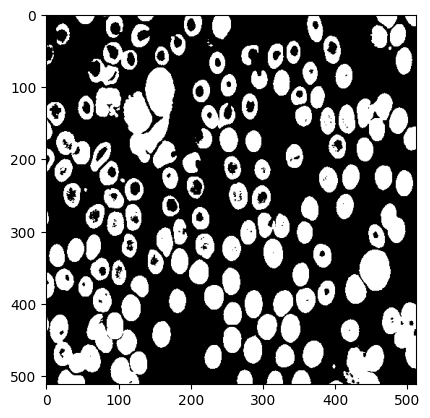

In [28]:
#load the cell image in grayscale and display it
img = plt.imread("imagesTP2/cell.tif")
threshold = 150
img = (img < threshold)

#display
plt.imshow(img, cmap = "gray")
plt.show()

We will first start by applying simple binary morphological operations on those images. You will try the following operations:
- erosion
- dilation
- opening
- closing

You will try various structuring elements (with `morpho.rectangle` or `morpho.disk` for example), with various sizes.

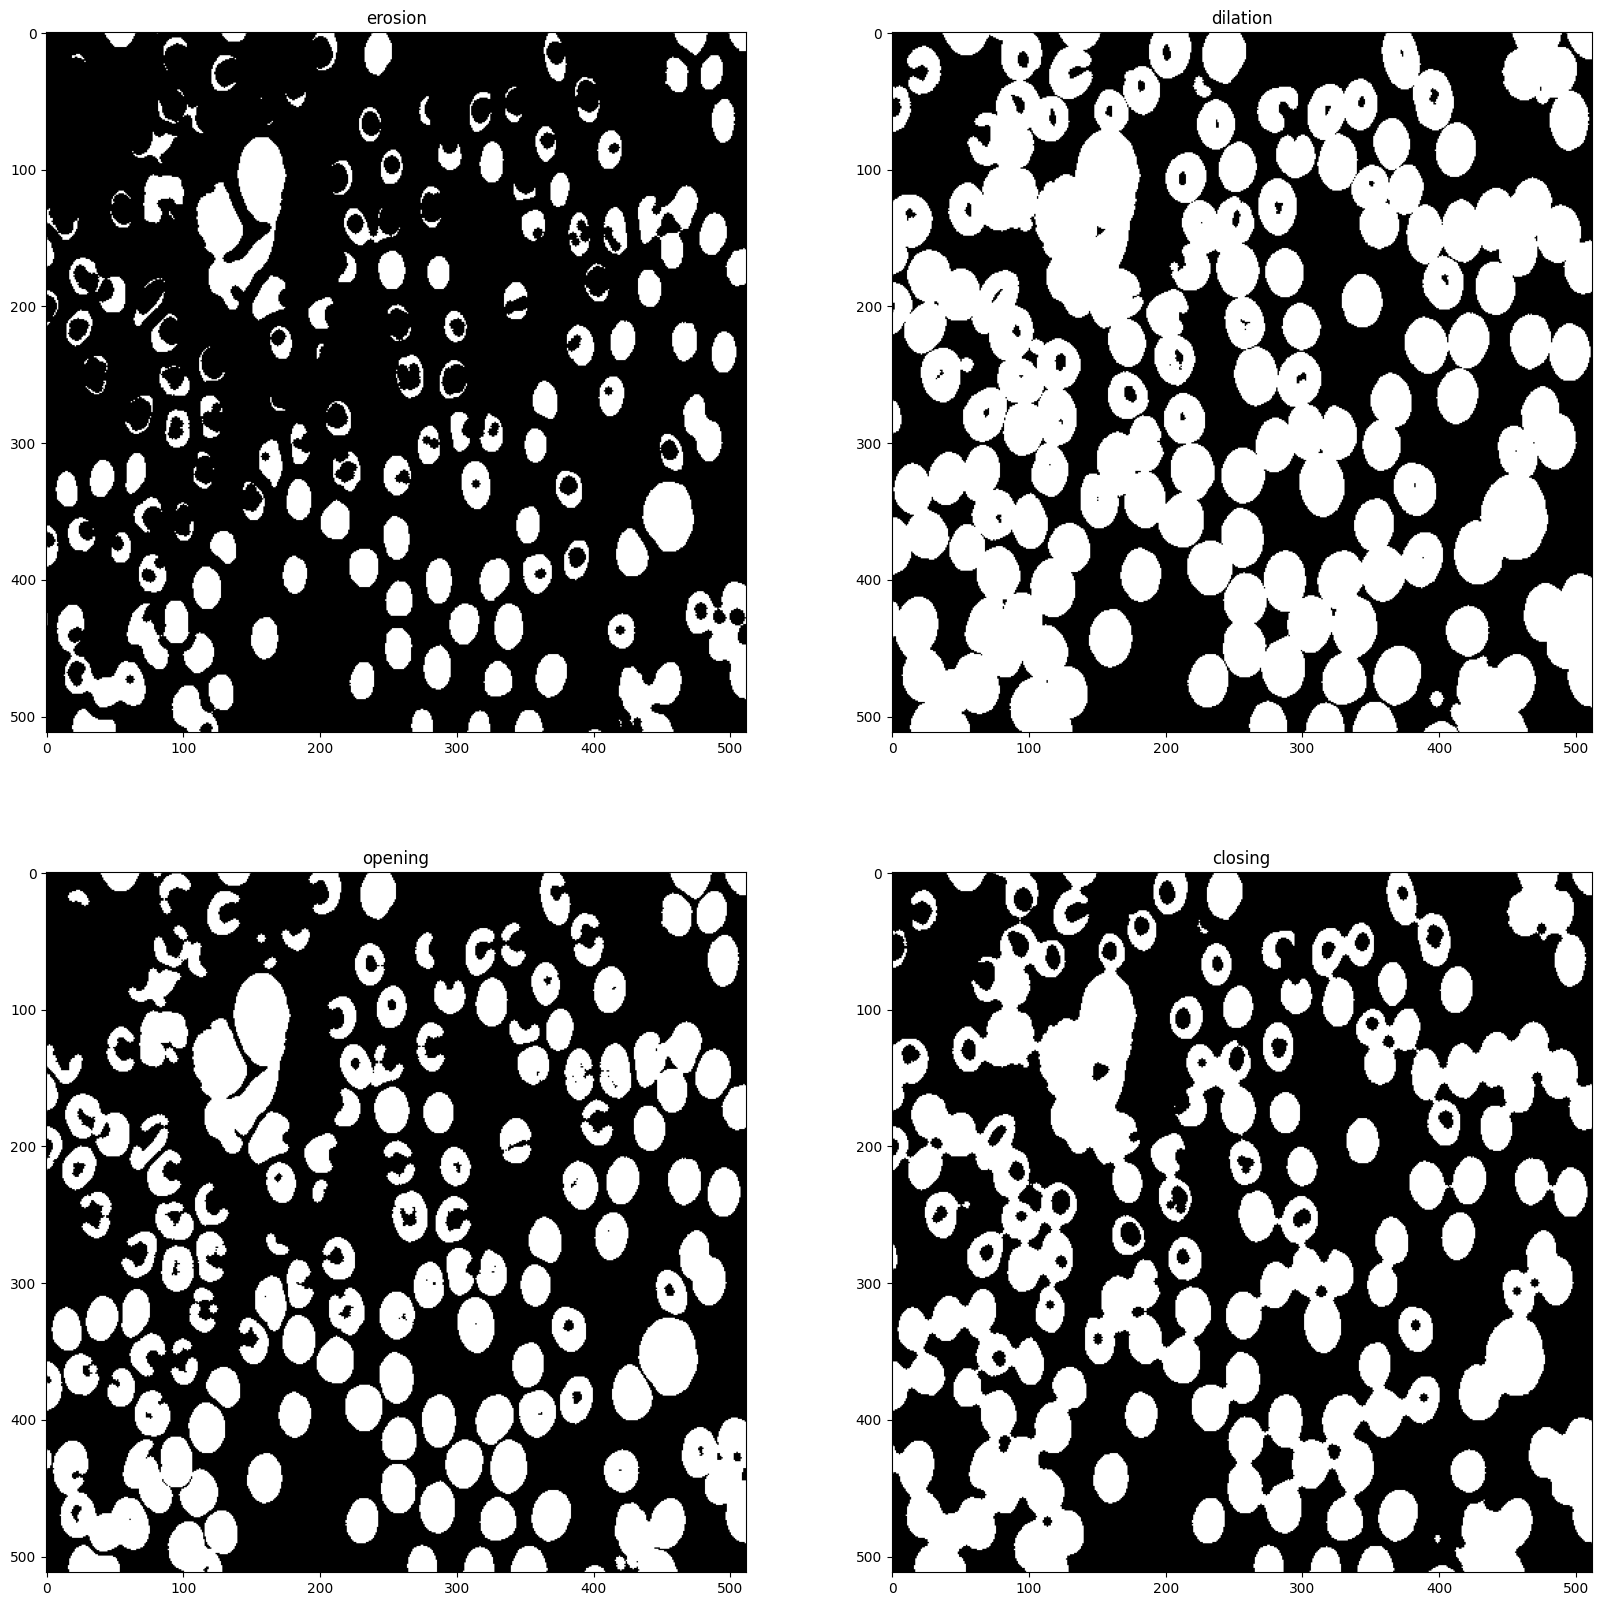

In [29]:

strell = morpho.disk(3)
fig,ax = plt.subplots(2, 2, figsize=(20,20))
imgs = [morpho.erosion(img,strell),morpho.dilation(img,strell),morpho.opening(img,strell),morpho.closing(img,strell)]

names = ["erosion","dilation","opening","closing"]
for i in range(4):
  ax[i//2,i%2].set_title(names[i])
  ax[i//2,i%2].imshow(imgs[i],cmap = "gray")
plt.show()

## Greyscale Dilation and Erosion

In this section, we will use the bateau.tif image. Make sure to load it and visualize it in greyscale.


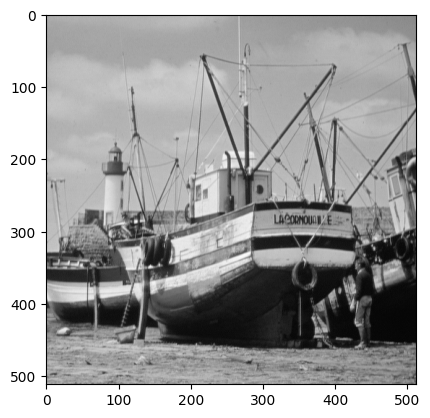

In [32]:
#load the bateau image in grayscale and display it
imga = plt.imread("imagesTP2/bateau.tif")
#display
plt.imshow(imga, cmap = "gray")
plt.show()

Apply the same 4 operations as before (dilation,erosion,opening,closing) and visualize the results. Try out different structuring elements and different sizes.

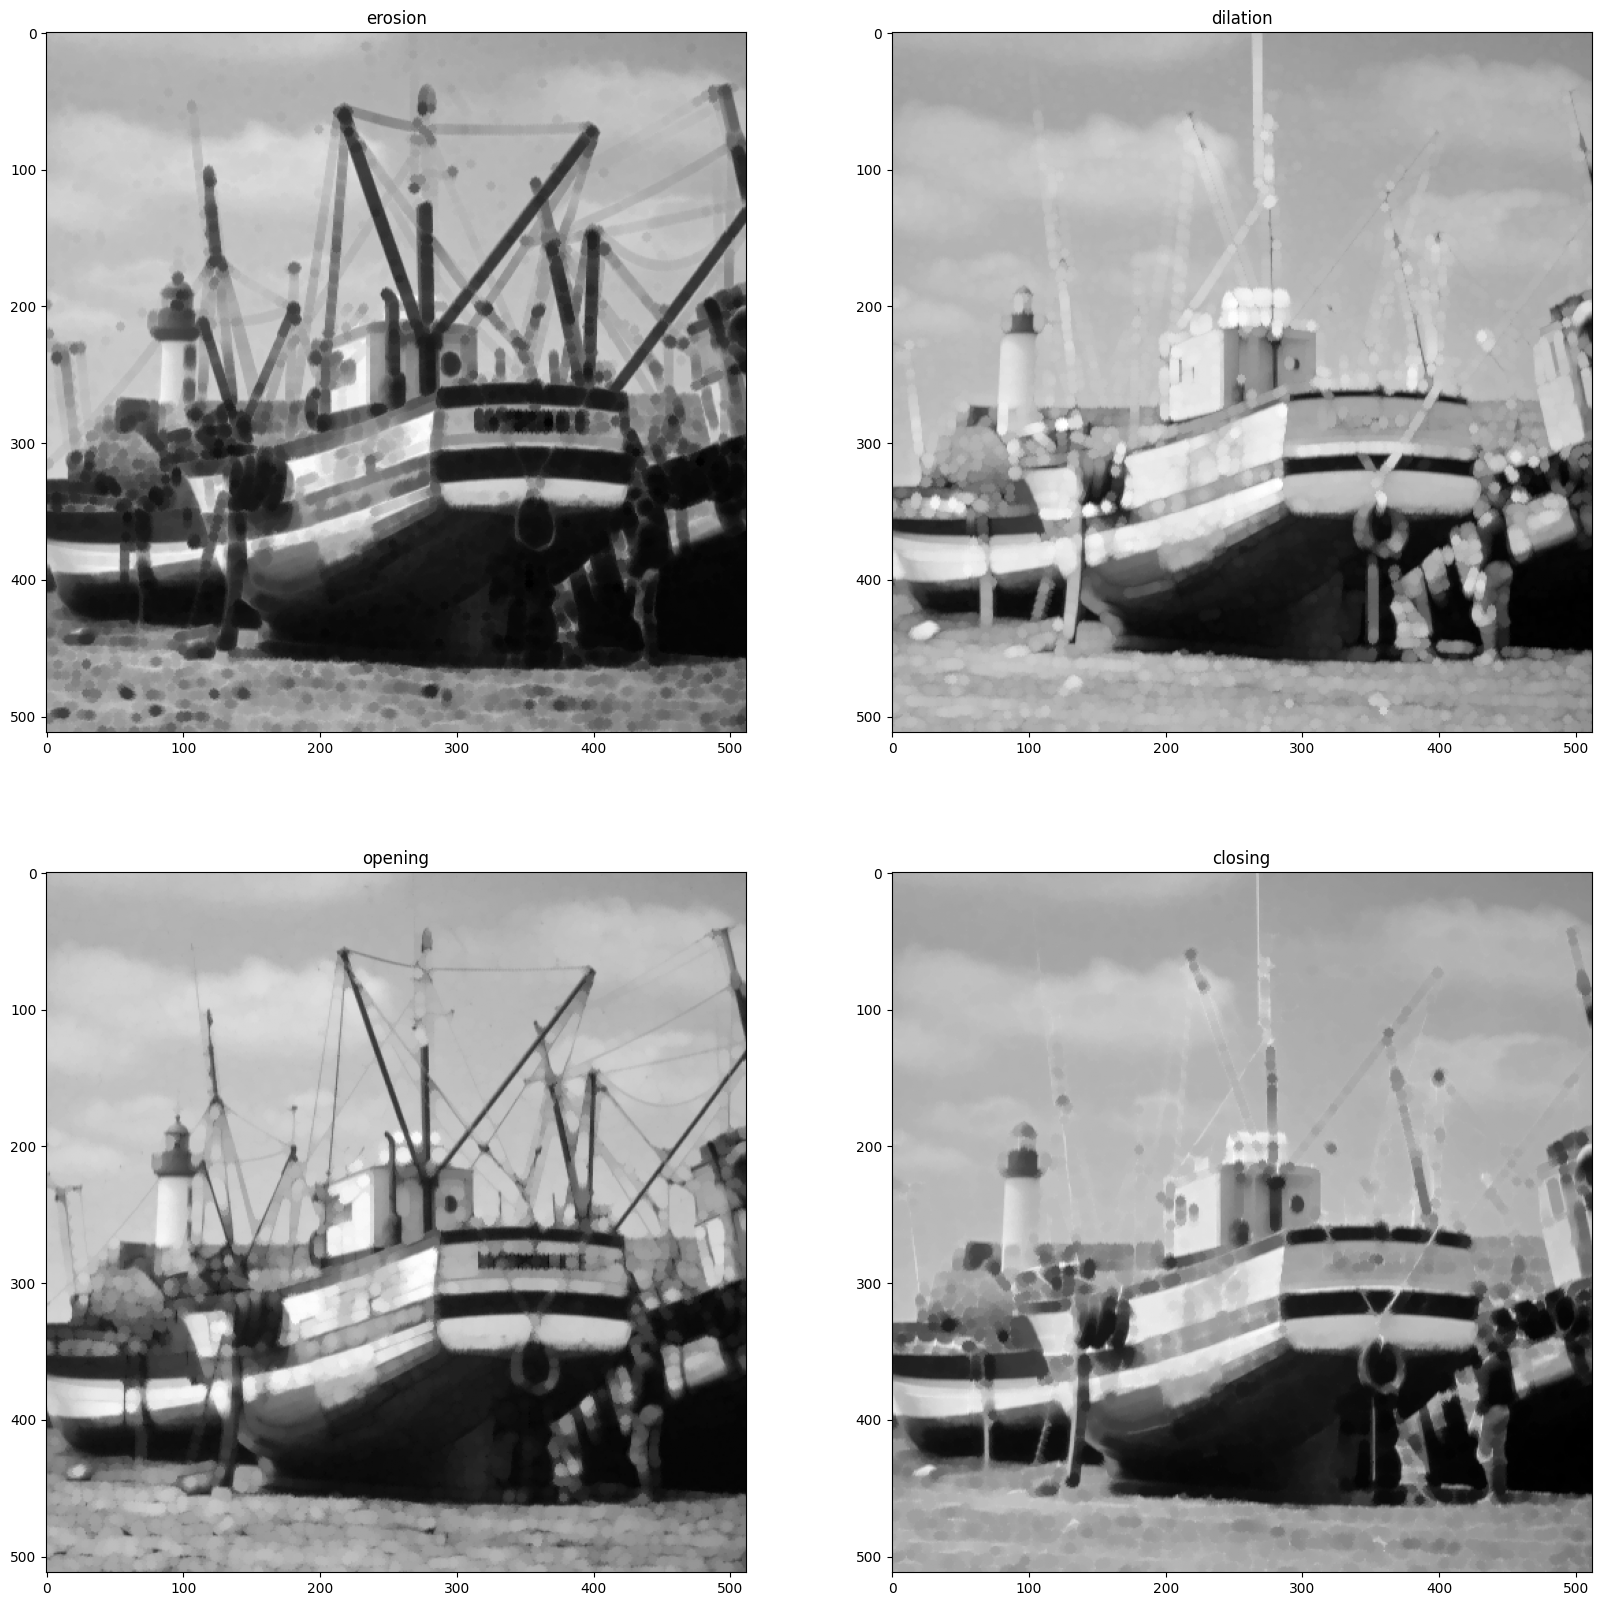

In [22]:
strell = morpho.disk(3)
fig,ax = plt.subplots(2, 2, figsize=(20,20))
imgs = [morpho.erosion(imga,strell),morpho.dilation(imga,strell),morpho.opening(imga, strell),morpho.closing(imga,strell)]

names = ["erosion","dilation","opening","closing"]
for i in range(4):
  ax[i//2,i%2].set_title(names[i])
  ax[i//2,i%2].imshow(imgs[i],cmap = "gray")
plt.show()

- **Q** : According to the iterativity property of the dilation, what is the expected result of a dilation by a structuring element of radius 1 followed by a dilation by a
structuring element of radius 2 (and same shape) ? Illustrate this example in the following cell.
- **A** : ...

Using a structuring element of radius 1 and a structuring element of radius 2 (and same shape), illustrate the iterative property of the dilation.

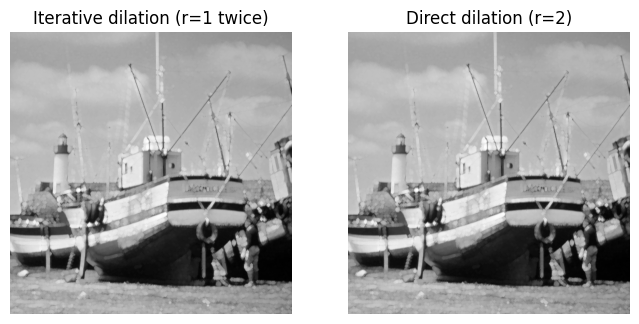

In [42]:
from skimage import morphology as morpho
import matplotlib.pyplot as plt

strell1 = morpho.disk(1)
strell2 = morpho.disk(2)

iterative = morpho.dilation(imga, strell1)
iterative = morpho.dilation(iterative, strell1)

direct = morpho.dilation(imga, strell2)

# Show results
fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].imshow(iterative, cmap='gray')
axes[0].set_title("Iterative dilation (r=1 twice)")
axes[0].axis('off')

axes[1].imshow(direct, cmap='gray')
axes[1].set_title("Direct dilation (r=2)")
axes[1].axis('off')

plt.show()

- **Q:** According to the idempotence property of the opening, what is the result of an opening by a structuring element of radius 2 followed by an opening by a structuring element of identical radius (and same shape) ? Illustrate this example in the following cell.
- **A:** ...


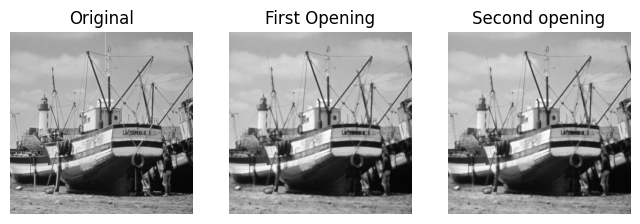

In [45]:
from skimage import morphology as morpho
import matplotlib.pyplot as plt

strell = morpho.disk(2)

first_opening = morpho.opening(imga, strell)
second_opening = morpho.opening(first_opening, strell)


# Show results
fig, axes = plt.subplots(1, 3, figsize=(8,4))
axes[0].imshow(imga, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(first_opening, cmap='gray')
axes[1].set_title("First Opening")
axes[1].axis('off')

axes[2].imshow(second_opening, cmap='gray')
axes[2].set_title("Second opening")
axes[2].axis('off')

plt.show()

## Top-hat transform

- **Q** : Perform a top-hat transform in the following cell (difference between the image and its opening).
Comment the result depending on the choice of the structuring element.
- **A** : ...

In [ ]:
### start code
strell = ...
top_hat = ...
plt.figure(figsize = (7,7))
plt.imshow(top_hat,cmap = "gray")
plt.show()

- **Q** : Perform a dual top-hat transform in the following cell (difference between the closing and the image).
Comment the result depending on the choice of the structuring element.
- **A** : ...

In [ ]:
### start code
strell = ...
dual_top_hat = ...
plt.figure(figsize = (7,7))
plt.imshow(dual_top_hat,cmap = "gray")
plt.show()

## Morphological Gradient

- **Q** : Apply a morphological gradient to the image cell.tif (difference between
dilation and erosion with a structuring element of radius1). What do you observe ?

In [ ]:
img = plt.imread("imagesTP2/cell.tif")
strell = ...
morpho_grad = ...
plt.figure(figsize=(15,15))
plt.imshow(morpho_grad,cmap = "gray")
plt.show()


- **Q** : Try to threshold the gradient with a value of 25 for instance. Why is is difficult to find an appropriate threshold value ?

In [ ]:
thresh_grad = ...
plt.imshow(thresh_grad,cmap  ="gray")
plt.show()